AIプログラミング2 11,12回目<br>
RNN

#1.RNNの実装



##(1)RNNを作る前にデータを作る。<br>
sinカーブと、誤差を入れたsinカーブ


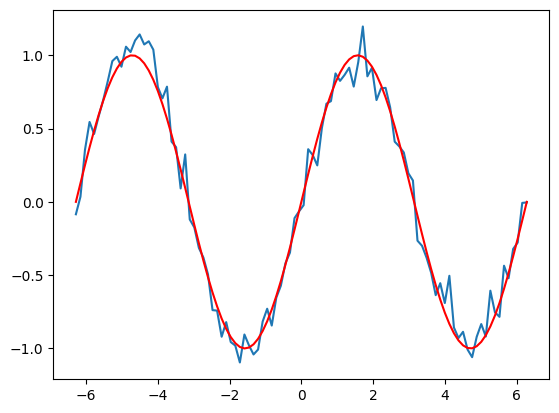

In [2]:
import torch
import math
import matplotlib.pyplot as plt

sin_x = torch.linspace(-2*math.pi, 2*math.pi, 100)  # -2πから2πまで
sin_y = torch.sin(sin_x)  + 0.1*torch.randn(len(sin_x))  # sin関数に乱数でノイズを加える
t_sin_y = torch.sin(sin_x)
plt.plot(sin_x, sin_y)
plt.plot(sin_x, t_sin_y, color='red')
plt.show()

###(2) ノイズ付きサインデータの前処理<br>
学習させる幅の処理<br>
Dataloderに変更してミニバッチで取り出しやすいように

In [5]:
from torch.utils.data import TensorDataset, DataLoader

n_time = 10  # 時刻の数
n_sample = len(sin_x)-n_time  # サンプル数

#0クリア初期化
input_data = torch.zeros((n_sample, n_time, 1))  # 入力
correct_data = torch.zeros((n_sample, 1))  # 正解
#print("input_data:",input_data)
#print("currect_data:",correct_data)

for i in range(n_sample):
    input_data[i] = sin_y[i:i+n_time].view(-1, 1)  # （時刻の数, 入力の数）
    correct_data[i] = sin_y[i+n_time:i+n_time+1]  # 正解は入力よりも1つ後
#    print("input_data:",input_data)
#    print("currect_data:",correct_data)

dataset = TensorDataset(input_data, correct_data)  # データセットの作成
train_loader = DataLoader(dataset, batch_size=8, shuffle=True)  # DataLoaderの設定

###(3)RNNモデルの構築

In [6]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(  # RNN層
            input_size=1,  # 入力数
            hidden_size=256,  # ニューロン数
            batch_first=True,  # 入力の形状を (バッチサイズ, 時刻の数, 入力の数) にする
        )
        self.fc = nn.Linear(256, 1)  # 全結合層

    def forward(self, x):
        # y_rnn:全時刻の出力 h:中間層の最終時刻の値
        y_rnn, h = self.rnn(x, None)
#        print("y_rnn_1",y_rnn)
#        print("y_rnn",y_rnn[:,-1,:])
        y = self.fc(y_rnn[:, -1, :])  # -1で最後の時刻のみ取得して全結合層へ渡す
        return y

net = Net()
print(net)

Net(
  (rnn): RNN(1, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


###(4)RNNモデルの学習

Epoch: 0 Loss_Train: 0.47844193627436954


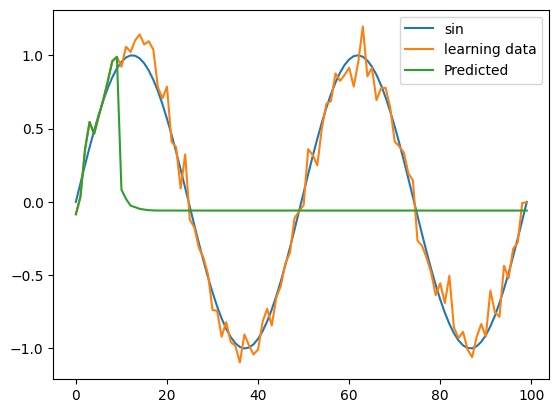

Epoch: 10 Loss_Train: 0.04133401392027736


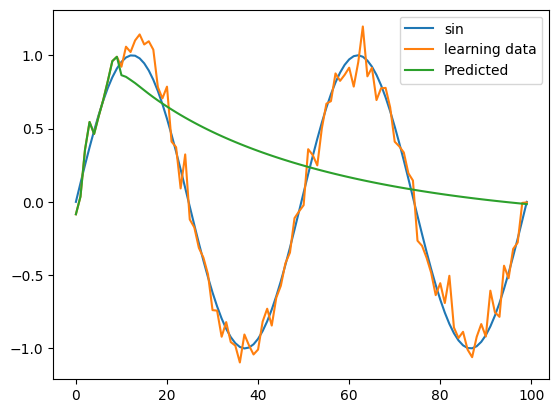

Epoch: 20 Loss_Train: 0.024190174454512697


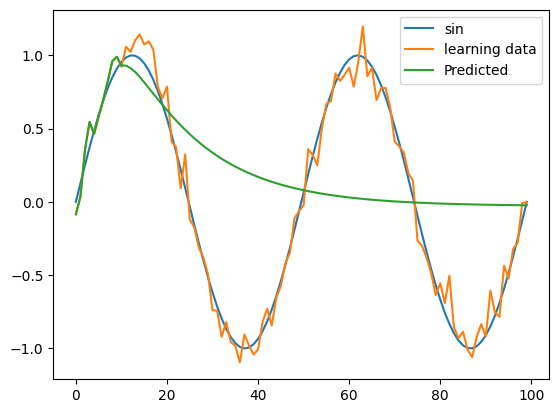

Epoch: 30 Loss_Train: 0.015720824672219653


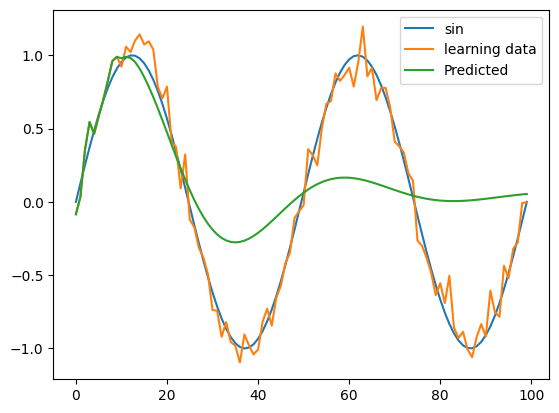

Epoch: 40 Loss_Train: 0.014125092168493817


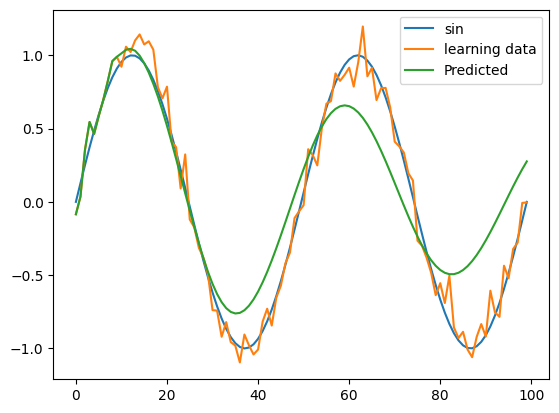

Epoch: 50 Loss_Train: 0.015862692632557202


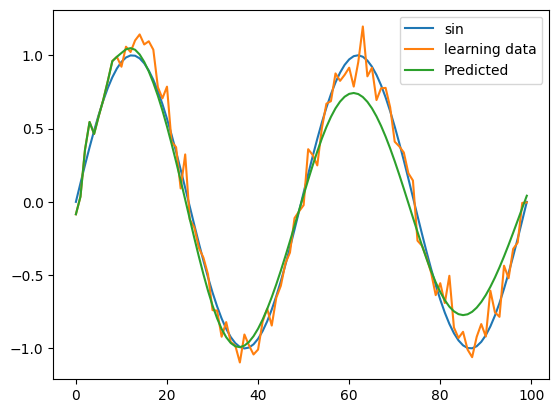

Epoch: 60 Loss_Train: 0.0166973127440239


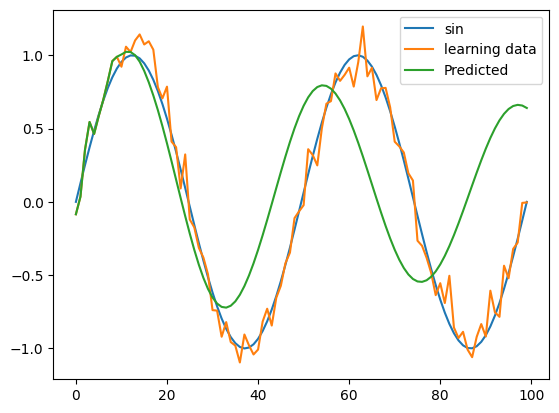

Epoch: 70 Loss_Train: 0.013618714622377107


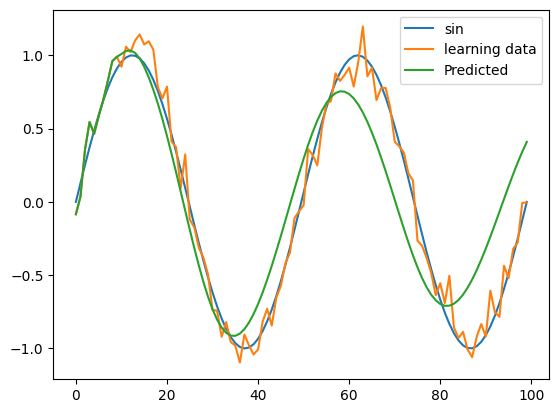

Epoch: 80 Loss_Train: 0.01433602902883043


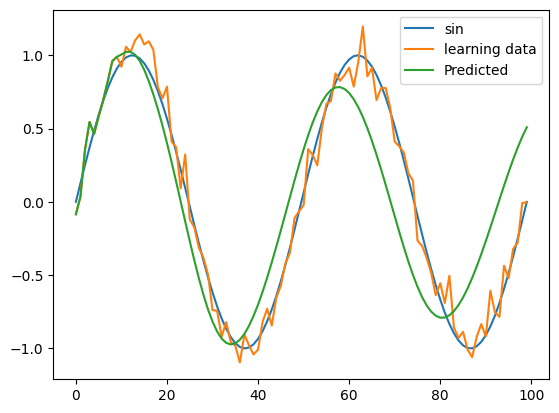

Epoch: 90 Loss_Train: 0.014952357159927487


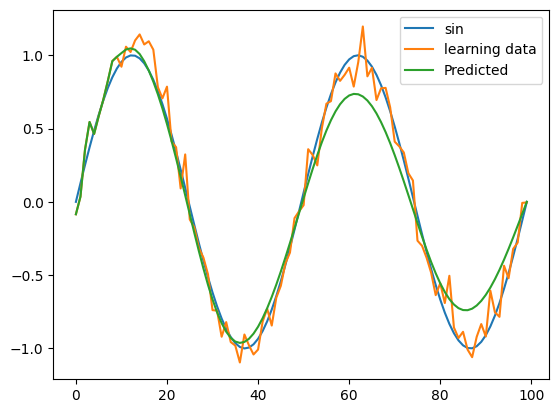

Epoch: 99 Loss_Train: 0.014789756038226187


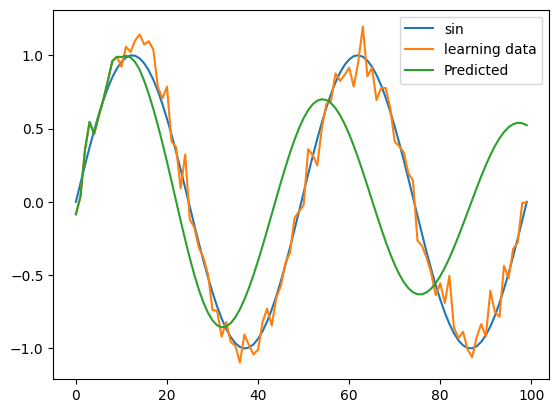

In [7]:
from torch import optim

# 平均二乗誤差
loss_fnc = nn.MSELoss()

# 最適化アルゴリズム
optimizer = optim.SGD(net.parameters(), lr=0.01)  # 学習率は0.01

# 損失のログ
record_loss_train = []

# 学習
epochs = 100  # エポック数
for i in range(epochs):
    net.train()  # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train /= j+1
    record_loss_train.append(loss_train)

    # 経過の表示
    if i%10==0 or i==epochs-1:
        net.eval()  # 評価モード
        print("Epoch:", i, "Loss_Train:", loss_train)
        predicted = list(input_data[0].view(-1)) # 最初の入力
        for i in range(n_sample):
            x = torch.tensor(predicted[-n_time:])  # 直近の時系列を取り出す
            x = x.view(1, n_time, 1)  # (バッチサイズ, 時刻の数, 入力の数)
            y = net(x)
            predicted.append(y[0].item())  # 予測結果をpredictedに追加する

        plt.plot(range(len(sin_y)), t_sin_y, label="sin")
        plt.plot(range(len(sin_y)), sin_y, label="learning data")
        plt.plot(range(len(predicted)), predicted, label="Predicted")
        plt.legend()
        plt.show()


###(5)誤差の推移

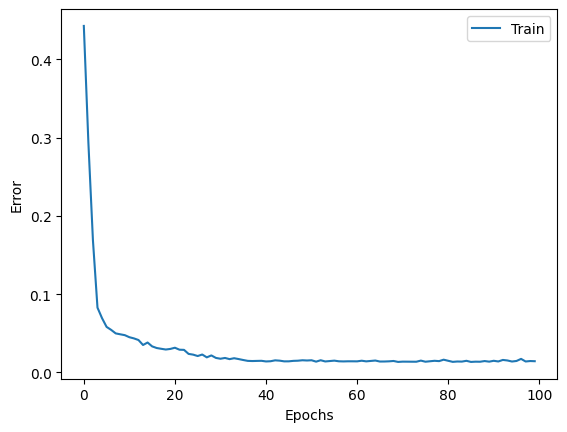

In [ ]:
plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

#課題1<br>
RNNの中間層の大きさを変えたときについて考察しなさい。<br>
hidden_size=○, ○, ○

Net(
  (rnn): RNN(1, 1024, batch_first=True)
  (fc): Linear(in_features=1024, out_features=1, bias=True)
)
Epoch: 0 Loss_Train: 0.4583383525411288


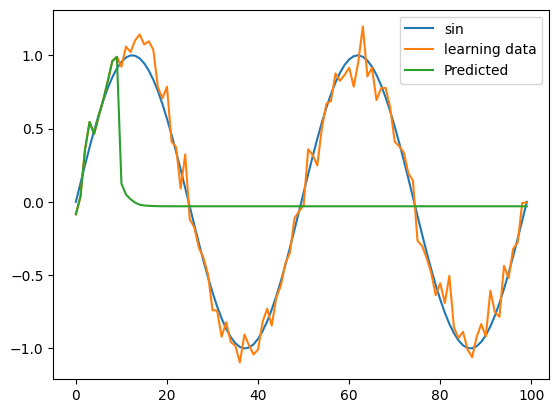

Epoch: 10 Loss_Train: 0.04467243126903971


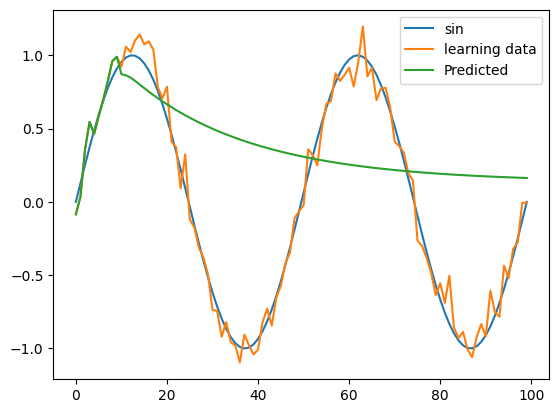

Epoch: 20 Loss_Train: 0.022726361562187474


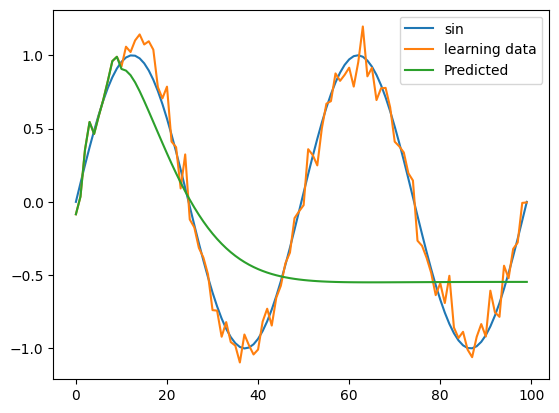

Epoch: 30 Loss_Train: 0.015417238600396862


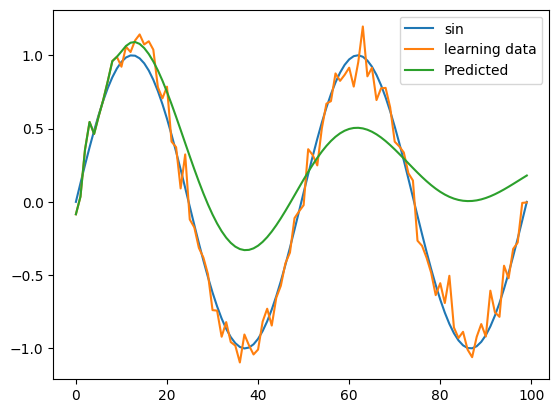

Epoch: 39 Loss_Train: 0.014224882307947459


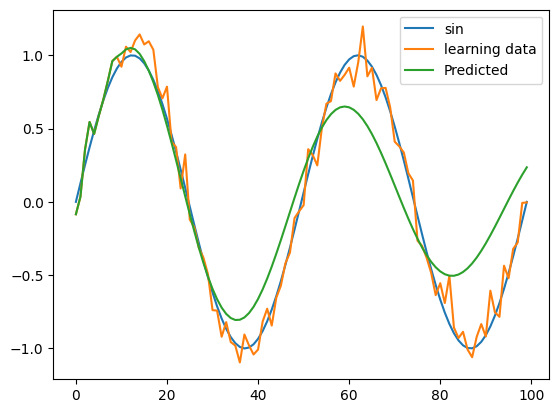

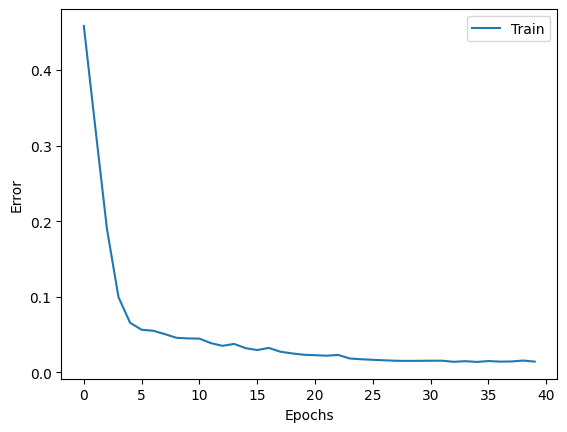

In [11]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(  # RNN層
            input_size=1,  # 入力数
            hidden_size=1024,  # ニューロン数
            batch_first=True,  # 入力の形状を (バッチサイズ, 時刻の数, 入力の数) にする
        )
        self.fc = nn.Linear(1024, 1)  # 全結合層

    def forward(self, x):
        # y_rnn:全時刻の出力 h:中間層の最終時刻の値
        y_rnn, h = self.rnn(x, None)#RNNとGRUのとき
        #y_rnn, (h, c) = self.rnn(x, None)#LSTMのとき
        y = self.fc(y_rnn[:, -1, :])  # -1で最後の時刻のみ取得して全結合層へ渡す
        return y

net = Net()
print(net)


###
from torch import optim

# 平均二乗誤差
loss_fnc = nn.MSELoss()

# 最適化アルゴリズム
optimizer = optim.SGD(net.parameters(), lr=0.01)  # 学習率は0.01

# 損失のログ
record_loss_train = []

# 学習
epochs = 40  # エポック数
for i in range(epochs):
    net.train()  # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train /= j+1
    record_loss_train.append(loss_train)

    # 経過の表示
    if i%10==0 or i==epochs-1:
        net.eval()  # 評価モード
        print("Epoch:", i, "Loss_Train:", loss_train)
        predicted = list(input_data[0].view(-1)) # 最初の入力
        for i in range(n_sample):
            x = torch.tensor(predicted[-n_time:])  # 直近の時系列を取り出す
            x = x.view(1, n_time, 1)  # (バッチサイズ, 時刻の数, 入力の数)
            y = net(x)
            predicted.append(y[0].item())  # 予測結果をpredictedに追加する

        plt.plot(range(len(sin_y)), t_sin_y, label="sin")
        plt.plot(range(len(sin_y)), sin_y, label="learning data")
        plt.plot(range(len(predicted)), predicted, label="Predicted")
        plt.legend()
        plt.show()

###
plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

#課題2<br>
RNNをモデルに使用しているが、<br>
GRUやLSTMに変更したときと比較しなさい。

Net(
  (rnn): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Epoch: 0 Loss_Train: 0.5266881411274275


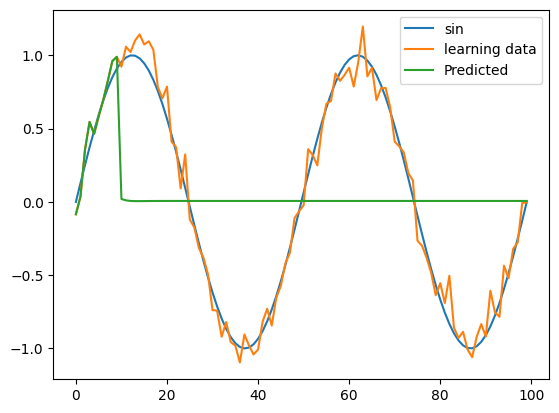

Epoch: 10 Loss_Train: 0.29833249809841317


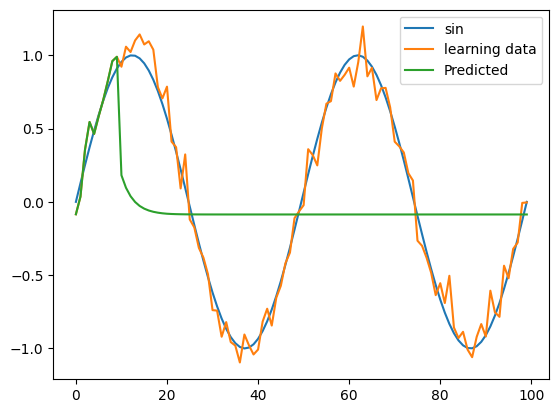

Epoch: 20 Loss_Train: 0.10675693924228351


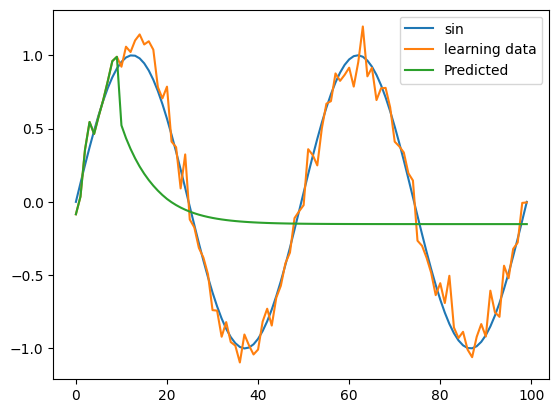

Epoch: 30 Loss_Train: 0.06115963434179624


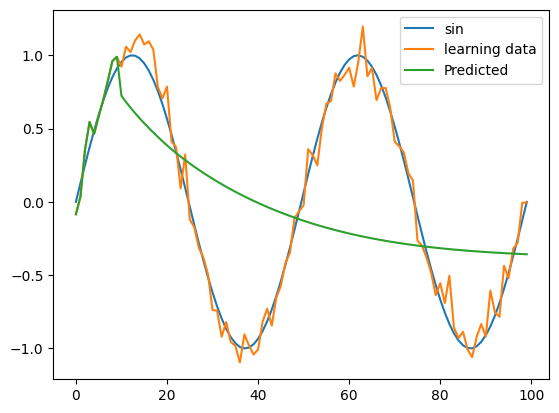

Epoch: 39 Loss_Train: 0.054180172427246966


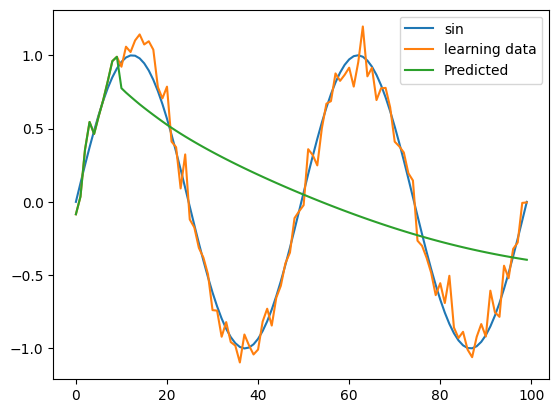

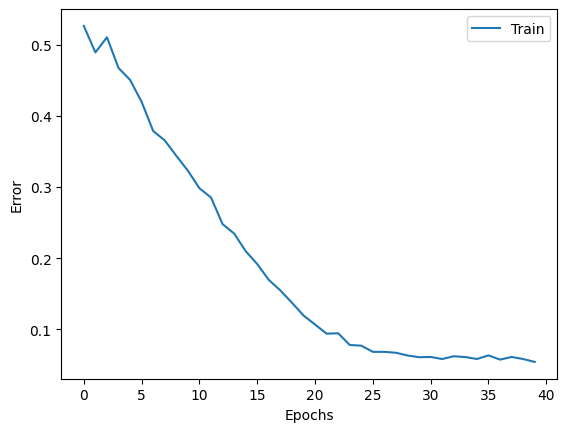

In [16]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.LSTM(  # RNN層
            input_size=1,  # 入力数
            hidden_size=64,  # ニューロン数
            batch_first=True,  # 入力の形状を (バッチサイズ, 時刻の数, 入力の数) にする
        )
        self.fc = nn.Linear(64, 1)  # 全結合層

    def forward(self, x):
        # y_rnn:全時刻の出力 h:中間層の最終時刻の値
        #y_rnn, h = self.rnn(x, None)#RNNとGRUのとき
        y_rnn, (h, c) = self.rnn(x, None)#LSTMのとき
        y = self.fc(y_rnn[:, -1, :])  # -1で最後の時刻のみ取得して全結合層へ渡す
        return y

net = Net()
print(net)


###
from torch import optim

# 平均二乗誤差
loss_fnc = nn.MSELoss()

# 最適化アルゴリズム
optimizer = optim.SGD(net.parameters(), lr=0.01)  # 学習率は0.01

# 損失のログ
record_loss_train = []

# 学習
epochs = 40  # エポック数
for i in range(epochs):
    net.train()  # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train /= j+1
    record_loss_train.append(loss_train)

    # 経過の表示
    if i%10==0 or i==epochs-1:
        net.eval()  # 評価モード
        print("Epoch:", i, "Loss_Train:", loss_train)
        predicted = list(input_data[0].view(-1)) # 最初の入力
        for i in range(n_sample):
            x = torch.tensor(predicted[-n_time:])  # 直近の時系列を取り出す
            x = x.view(1, n_time, 1)  # (バッチサイズ, 時刻の数, 入力の数)
            y = net(x)
            predicted.append(y[0].item())  # 予測結果をpredictedに追加する

        plt.plot(range(len(sin_y)), t_sin_y, label="sin")
        plt.plot(range(len(sin_y)), sin_y, label="learning data")
        plt.plot(range(len(predicted)), predicted, label="Predicted")
        plt.legend()
        plt.show()

###
plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()